# Minimal Burgers surrogate and joint PDE fitting

This notebook extracts only the requested path from `burgers_minimal_discovery_story.ipynb`:

1. load the generated Burgers dataset,
2. fit the SIREN surrogate to solution data only,
3. continue from that fitted surrogate while jointly training a randomly initialized one-product SymNet, and
4. expand and print the learned PDE.

The implementation reuses the repository's `solve_burgers`, `SirenMLP`, canonical `FeatureTensor`, `MinimalSymNet`, and exact product-coefficient expansion. The true equation is shown only for comparison: $u_t=-u u_x+0.02u_{xx}$.

In [1]:
from __future__ import annotations

import copy
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Make imports work whether Jupyter starts in the repository root or beside this notebook.
cwd = Path.cwd().resolve()
repo_root = next(
    (candidate for candidate in (cwd, *cwd.parents) if (candidate / 'prog').is_dir() and (candidate / 'Datasets').is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError('Could not locate the pde_stuff repository root.')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

from Datasets.data.processed.burg_gen.burg_gen import solve_burgers
from prog.featlib import FeatureTensor
from prog.minimal_symnet import MinimalSymNet, product_term_dict
from prog.mlps import SirenMLP
from utils.derivative_utils import (
    build_burgers_reference_derivative_grids,
    evaluate_model_primitive_features,
)

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'repository = {repo_root}')
print(f'device = {device}; seed = {SEED}')

repository = C:\Users\032480329\Documents\pde_stuff
device = cpu; seed = 0


In [2]:
# Settings retained from the source notebook's minimal experiments.
NU_TRUE = 0.02
HIDDEN_SIZE = 64
HIDDEN_LAYERS = 3
FIRST_OMEGA_0 = 1.0   # Paul change
HIDDEN_OMEGA_0 = 1.0

DATA_ADAM_STEPS = 2500
DATA_LBFGS_STEPS = 200
DATA_BATCH_SIZE = 4096
DATA_LR = 1e-3
NUM_TIME_SAMPLES = 10   # Paul change
NUM_SPACE_SAMPLES = 64  # Paul change

JOINT_STEPS = 1000
JOINT_BATCH_SIZE = 4096
JOINT_LR = 5e-4
LAMBDA_DATA = 1.0
LAMBDA_PDE = 1.0    # Paul change
LAMBDA_SYMNET_L1 = 0.0
LOG_EVERY = 100

FEATURE_TERMS = ('u', 'u_x', 'u_xx')
TERM_ORDER = ('u', 'u_x', 'u_xx', 'u^2', 'u*u_x', 'u*u_xx', 'u_x^2', 'u_x*u_xx', 'u_xx^2')

## 1. Load the generated Burgers dataset

`solve_burgers` supplies the clean periodic rollout used by the source notebook. Ten indices are selected by `np.linspace` over each of `t_grid` and `x_grid`, giving a 10×10 neural-network training grid. Separate full-grid tensors are retained for evaluation. Flattening is time-major, then spatial-minor, so each row is one physical-coordinate sample `(t, x, u)`.

In [3]:
x_grid, _u_final, _t_end, (t_grid, u_grid) = solve_burgers(
    seed=SEED, nu=NU_TRUE, return_history=True, T=0.1,   # Paul change, final time goes only to 0.1 instead of 1. 
)
x_grid = np.asarray(x_grid, dtype=np.float32)
t_grid = np.asarray(t_grid, dtype=np.float32)
u_grid = np.asarray(u_grid, dtype=np.float32)

time_sample_indices = np.linspace(0, len(t_grid) - 1, NUM_TIME_SAMPLES, dtype=int)
if len(np.unique(time_sample_indices)) != NUM_TIME_SAMPLES:
    raise ValueError('t_grid is too short to select 10 distinct evenly spaced indices.')
space_sample_indices = np.linspace(0, len(x_grid) - 1, NUM_SPACE_SAMPLES, dtype=int)
if len(np.unique(space_sample_indices)) != NUM_SPACE_SAMPLES:
    raise ValueError('x_grid is too short to select 10 distinct evenly spaced indices.')
sampled_t_grid = t_grid[time_sample_indices]
sampled_x_grid = x_grid[space_sample_indices]
sampled_u_grid = u_grid[np.ix_(time_sample_indices, space_sample_indices)]

T_train_mesh = np.repeat(sampled_t_grid[:, None], NUM_SPACE_SAMPLES, axis=1)
X_train_mesh = np.repeat(sampled_x_grid[None, :], NUM_TIME_SAMPLES, axis=0)
t_train = torch.tensor(T_train_mesh.reshape(-1), dtype=torch.float32, device=device).reshape(-1, 1)
x_train = torch.tensor(X_train_mesh.reshape(-1), dtype=torch.float32, device=device).reshape(-1, 1)
u_train = torch.tensor(sampled_u_grid.reshape(-1), dtype=torch.float32, device=device).reshape(-1, 1)
data_batch_size = min(DATA_BATCH_SIZE, len(t_train))
joint_batch_size = min(JOINT_BATCH_SIZE, len(t_train))

T_full_mesh = np.repeat(t_grid[:, None], len(x_grid), axis=1)
X_full_mesh = np.repeat(x_grid[None, :], len(t_grid), axis=0)
t_full = torch.tensor(T_full_mesh.reshape(-1), dtype=torch.float32, device=device).reshape(-1, 1)
x_full = torch.tensor(X_full_mesh.reshape(-1), dtype=torch.float32, device=device).reshape(-1, 1)
u_full = torch.tensor(u_grid.reshape(-1), dtype=torch.float32, device=device).reshape(-1, 1)

print(f'x grid: {x_grid.shape}; t grid: {t_grid.shape}; solution grid: {u_grid.shape}')
print('sampled time indices:', time_sample_indices.tolist())
print('sampled times:', np.round(sampled_t_grid, 6).tolist())
print('sampled space indices:', space_sample_indices.tolist())
print('sampled x values:', np.round(sampled_x_grid, 6).tolist())
print(f'training tensors: t={tuple(t_train.shape)}, x={tuple(x_train.shape)}, u={tuple(u_train.shape)}')
print(f'effective batch sizes: data={data_batch_size}, joint={joint_batch_size}')
print(f'true PDE: u_t = -u*u_x + {NU_TRUE}*u_xx')

x grid: (256,); t grid: (51,); solution grid: (51, 256)
sampled time indices: [0, 5, 11, 16, 22, 27, 33, 38, 44, 50]
sampled times: [0.0, 0.009999999776482582, 0.02199999988079071, 0.03200000151991844, 0.04399999976158142, 0.05400000140070915, 0.06599999964237213, 0.07599999755620956, 0.08799999952316284, 0.10000000149011612]
sampled space indices: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 85, 89, 93, 97, 101, 105, 109, 113, 117, 121, 125, 129, 133, 137, 141, 145, 149, 153, 157, 161, 165, 170, 174, 178, 182, 186, 190, 194, 198, 202, 206, 210, 214, 218, 222, 226, 230, 234, 238, 242, 246, 250, 255]
sampled x values: [0.0, 0.09817499667406082, 0.19634999334812164, 0.29452401399612427, 0.3926990032196045, 0.4908739924430847, 0.5890489816665649, 0.6872230172157288, 0.785398006439209, 0.8835729956626892, 0.9817479848861694, 1.0799219608306885, 1.1780970096588135, 1.2762720584869385, 1.374446988105774, 1.472622036933899, 1.570796012878418, 1.66897094249

## 2. Fit the surrogate to data only

This is the source notebook's SIREN data fit: random mini-batch Adam followed by full-grid L-BFGS. No PDE term participates in this stage.

In [4]:
surrogate = SirenMLP(
    hidden_size=HIDDEN_SIZE,
    hidden_layers=HIDDEN_LAYERS,
    first_omega_0=FIRST_OMEGA_0,
    hidden_omega_0=HIDDEN_OMEGA_0,
).to(device)

loss_fn = nn.MSELoss()
data_optimizer = torch.optim.Adam(surrogate.parameters(), lr=DATA_LR)
data_history = []

for step in range(1, DATA_ADAM_STEPS + 1):
    idx = torch.randint(0, len(t_train), (data_batch_size,), device=device)
    prediction = surrogate(t_train[idx], x_train[idx])
    data_loss = loss_fn(prediction, u_train[idx])

    data_optimizer.zero_grad(set_to_none=True)
    data_loss.backward()
    data_optimizer.step()

    if step == 1 or step % 250 == 0:
        with torch.no_grad():
            sampled_data_mse = loss_fn(surrogate(t_train, x_train), u_train).item()
        data_history.append({'stage': 'Adam', 'step': step, 'sampled_data_mse': sampled_data_mse})
        print(f'Adam step {step:4d} | sampled-grid data MSE = {sampled_data_mse:.6e}')

lbfgs = torch.optim.LBFGS(
    surrogate.parameters(),
    lr=1.0,
    max_iter=DATA_LBFGS_STEPS,
    history_size=50,
    line_search_fn='strong_wolfe',
)

def lbfgs_closure():
    lbfgs.zero_grad(set_to_none=True)
    loss = loss_fn(surrogate(t_train, x_train), u_train)
    loss.backward()
    return loss

lbfgs.step(lbfgs_closure)
with torch.no_grad():
    final_data_only_sampled_mse = loss_fn(surrogate(t_train, x_train), u_train).item()
    final_data_only_full_mse = loss_fn(surrogate(t_full, x_full), u_full).item()
print(f'final data-only sampled-grid MSE = {final_data_only_sampled_mse:.6e}')
print(f'final data-only full-grid MSE = {final_data_only_full_mse:.6e}')

Adam step    1 | sampled-grid data MSE = 1.633800e+00
Adam step  250 | sampled-grid data MSE = 4.705276e-02
Adam step  500 | sampled-grid data MSE = 3.862253e-03
Adam step  750 | sampled-grid data MSE = 1.698611e-03
Adam step 1000 | sampled-grid data MSE = 1.318617e-03
Adam step 1250 | sampled-grid data MSE = 1.029561e-03
Adam step 1500 | sampled-grid data MSE = 7.852163e-04
Adam step 1750 | sampled-grid data MSE = 6.401095e-04
Adam step 2000 | sampled-grid data MSE = 5.547178e-04
Adam step 2250 | sampled-grid data MSE = 5.101547e-04
Adam step 2500 | sampled-grid data MSE = 4.883776e-04
final data-only sampled-grid MSE = 2.107001e-04
final data-only full-grid MSE = 1.820197e-04


feature comparison at t = 0.054000 (t_grid index 27)


,true_l2,surrogate_l2,error_l2,relative_l2_error
feature,,,,
u_xx,88.050309,88.949196,17.342406,0.19696
u*u_x,16.750673,16.859798,1.287790,0.07688


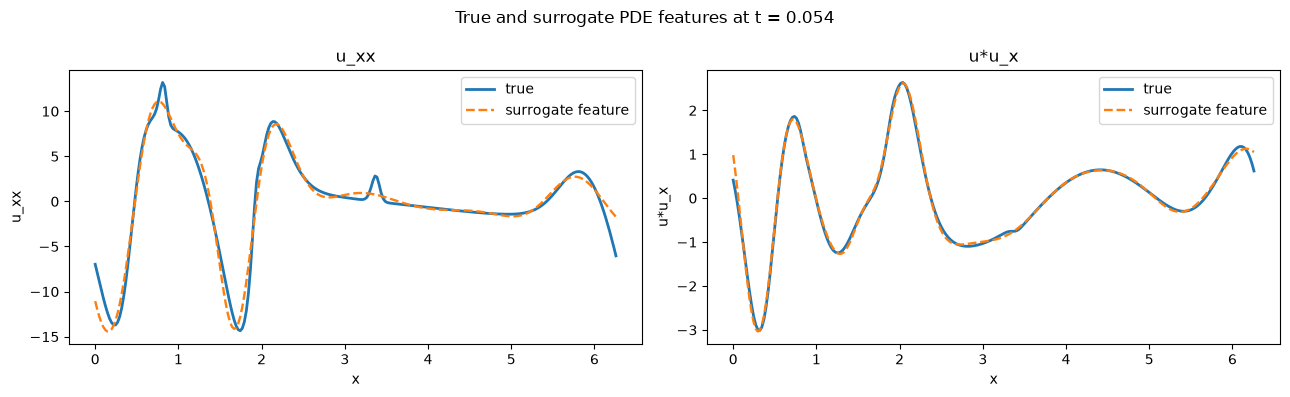

In [5]:
# Compare canonical surrogate features with generator-consistent references at one sampled time.
snapshot_position = NUM_TIME_SAMPLES // 2
snapshot_index = int(time_sample_indices[snapshot_position])
snapshot_time = float(t_grid[snapshot_index])
snapshot_t = np.full(x_grid.shape, snapshot_time, dtype=np.float32)

model_features = evaluate_model_primitive_features(
    surrogate, snapshot_t, x_grid, FEATURE_TERMS, device=device, normalize=False,
)
model_feature_by_name = {
    name: model_features['values'][:, column]
    for column, name in enumerate(model_features['feature_names'])
}
reference_features = build_burgers_reference_derivative_grids(
    u_grid=u_grid, x_grid=x_grid, nu=NU_TRUE,
)
ut_true = reference_features['u_t']['physical'][snapshot_index]

comparison = {
    'u_xx': (
        reference_features['u_xx']['physical'][snapshot_index],
        model_feature_by_name['u_xx'],
    ),
    'u*u_x': (
        reference_features['u*u_x']['physical'][snapshot_index],
        model_feature_by_name['u'] * model_feature_by_name['u_x'],
    ),
}

l2_rows = []
for name, (true_values, surrogate_values) in comparison.items():
    true_l2 = float(np.linalg.norm(true_values))
    surrogate_l2 = float(np.linalg.norm(surrogate_values))
    error_l2 = float(np.linalg.norm(surrogate_values - true_values))
    l2_rows.append({
        'feature': name,
        'true_l2': true_l2,
        'surrogate_l2': surrogate_l2,
        'error_l2': error_l2,
        'relative_l2_error': error_l2 / max(true_l2, 1e-12),
    })
l2_comparison = pd.DataFrame(l2_rows).set_index('feature')
print(f'feature comparison at t = {snapshot_time:.6f} (t_grid index {snapshot_index})')
display(l2_comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for ax, (name, (true_values, surrogate_values)) in zip(axes, comparison.items()):
    ax.plot(x_grid, true_values, label='true', linewidth=2)
    ax.plot(x_grid, surrogate_values, '--', label='surrogate feature', linewidth=1.7)
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel(name)
    ax.legend(loc='best')
fig.suptitle(f'True and surrogate PDE features at t = {snapshot_time:.3f}')
fig.tight_layout()
plt.show()

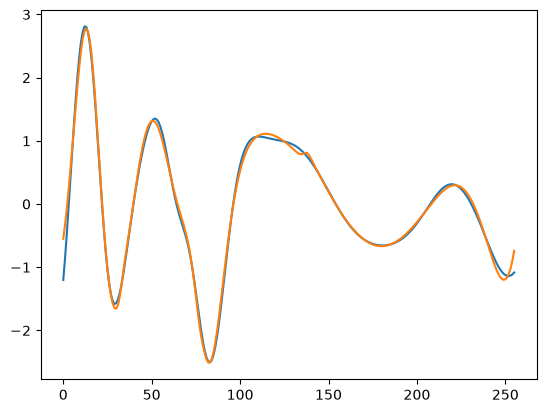

In [6]:
plt.plot(0.02*comparison['u_xx'][1]- comparison['u*u_x'][1])
plt.plot(ut_true)

In [7]:
# Exact Burgers SymNet evaluated on the data-only surrogate features.
t0 = torch.full((len(x_grid), 1), snapshot_time, device=device, requires_grad=True)
x0 = torch.tensor(x_grid, device=device).reshape(-1, 1).requires_grad_(True)
u0 = surrogate(t0, x0)
ut0 = torch.autograd.grad(u0, t0, torch.ones_like(u0), create_graph=True)[0]
F0 = FeatureTensor(FEATURE_TERMS, normalize=False).build(u0, x=x0).F
joint_symnet = MinimalSymNet().to(device)
with torch.no_grad():
    for parameter in joint_symnet.parameters(): parameter.zero_()
    joint_symnet.left.weight[0, 0] = 1.0
    joint_symnet.right.weight[0, 1] = 1.0
    joint_symnet.product_readout.weight[0, 0] = -1.0
    joint_symnet.linear.weight[0, 2] = NU_TRUE
pde_loss = loss_fn(ut0, joint_symnet(F0))
F_true = torch.tensor(np.column_stack([reference_features[name]['physical'][snapshot_index] for name in FEATURE_TERMS]), dtype=torch.float32, device=device)
ut_true = torch.tensor(reference_features['u_t']['physical'][snapshot_index], dtype=torch.float32, device=device).reshape(-1, 1)
print(product_term_dict(joint_symnet))
print(f'exact-Burgers PDE loss on reference features: {loss_fn(ut_true, joint_symnet(F_true)).item():.6e}')
print(f'exact-Burgers PDE loss on surrogate features: {pde_loss.item():.6e}')

{'u': 0.0, 'u_x': 0.0, 'u_xx': 0.019999999552965164, 'u^2': -0.0, 'u*u_x': -1.0, 'u*u_xx': -0.0, 'u_x^2': -0.0, 'u_x*u_xx': -0.0, 'u_xx^2': -0.0}
exact-Burgers PDE loss on reference features: 3.167456e-15
exact-Burgers PDE loss on surrogate features: 1.805557e-01


## 3. Joint surrogate and PDE fitting

Joint training begins from the fitted data-only surrogate. The SymNet is randomly initialized. At every step, autograd supplies $u_t$, while the canonical `FeatureTensor` constructs the physical primitive library $[u,u_x,u_{xx}]$. Both models minimize

$$L=L_{data}+0.01L_{PDE}+10^{-5}\lVert\theta_{SymNet}\rVert_1, \qquad L_{PDE}=\operatorname{MSE}(u_t,\operatorname{SymNet}[u,u_x,u_{xx}]).$$

Feature normalization is disabled here, matching the source notebook's minimal random-joint experiment; the expanded coefficients are therefore already in physical feature coordinates.

In [8]:
# Preserve the data-only model for comparison and continue from a copy.
# joint_surrogate = copy.deepcopy(surrogate).to(device)
joint_surrogate = SirenMLP(   # Paul change. So surrogation parameters don't pass to joint training, but it will reinitialize all the parameters. 
    hidden_size=HIDDEN_SIZE,
    hidden_layers=HIDDEN_LAYERS,
    first_omega_0=FIRST_OMEGA_0,
    hidden_omega_0=HIDDEN_OMEGA_0,
).to(device)
torch.manual_seed(SEED)
joint_symnet = MinimalSymNet().to(device)
feature_builder = FeatureTensor(terms=FEATURE_TERMS, normalize=False)
# with torch.no_grad():
#     # for parameter in joint_symnet.parameters(): parameter.zero_()
#     for parameter in joint_symnet.left.parameters(): parameter.zero_()
#     for parameter in joint_symnet.right.parameters(): parameter.zero_()
#     for parameter in joint_symnet.product_readout.parameters(): parameter.zero_()
#     joint_symnet.left.weight[0, 0] = 1.0
#     joint_symnet.right.weight[0, 1] = 1.0
#     joint_symnet.product_readout.weight[0, 0] = -1.0
#     joint_symnet.linear.weight[0, 2] = NU_TRUE
    
joint_optimizer = torch.optim.Adam(
    list(joint_surrogate.parameters()) + list(joint_symnet.parameters()),
    lr=JOINT_LR,
)
joint_history = []
LOG_EVERY = 100
JOINT_STEPS = 100000
for step in range(JOINT_STEPS + 1):
    idx = torch.randint(0, len(t_train), (joint_batch_size,), device=device)
    t_batch = t_train[idx].detach().clone().requires_grad_(True)
    x_batch = x_train[idx].detach().clone().requires_grad_(True)
    u_batch_true = u_train[idx]

    u_batch_pred = joint_surrogate(t_batch, x_batch)
    u_t = torch.autograd.grad(
        u_batch_pred, t_batch, grad_outputs=torch.ones_like(u_batch_pred),
        create_graph=True, retain_graph=True,
    )[0]
    features = feature_builder.build(u_batch_pred, t=t_batch, x=x_batch)
    pde_rhs = joint_symnet(features.F)

    data_loss = loss_fn(u_batch_pred, u_batch_true)
    pde_loss = loss_fn(u_t, pde_rhs)
    symnet_l1 = sum(parameter.abs().sum() for parameter in joint_symnet.parameters())
    l1_loss = LAMBDA_SYMNET_L1 * symnet_l1     # Paul change. Although I computed l1_loss, I haven't added that to the total_loss yet. 
    ut_norm = loss_fn(u_t, torch.zeros_like(u_t))     # Paul change. Although I computed l1_loss, I haven't added that to the total_loss yet. 
    total_loss = LAMBDA_DATA * data_loss + LAMBDA_PDE * pde_loss 

    if step == 0 or step % LOG_EVERY == 0 or step == JOINT_STEPS:
        row = {
            'step': step,
            'data_mse': float(data_loss.item()),
            'pde_mse': float(pde_loss.item()),
            'symnet_l1': float(symnet_l1.item()),
            'l1_loss': float(l1_loss.item()),
            'total_loss': float(total_loss.item()),
        }
        row.update(product_term_dict(joint_symnet))
        joint_history.append(row)
        print(
            f"step {step:4d} | data MSE = {row['data_mse']:.6e} | "
            f"PDE MSE = {row['pde_mse']:.6e} | "
            f"L1 loss = {row['l1_loss']:.6e} | "
            f"c(u*u_x) = {row['u*u_x']:+.6f} | c(u_xx) = {row['u_xx']:+.6f} | "
            f"{ut_norm.item():}"
        )

    if step == JOINT_STEPS:
        break

    joint_optimizer.zero_grad(set_to_none=True)
    total_loss.backward()
    joint_optimizer.step()

joint_history_df = pd.DataFrame(joint_history)

step    0 | data MSE = 1.632410e+00 | PDE MSE = 1.707244e-01 | L1 loss = 0.000000e+00 | c(u*u_x) = -0.034568 | c(u_xx) = -0.051236 | 0.07412126660346985
step  100 | data MSE = 8.843414e-02 | PDE MSE = 2.309666e-03 | L1 loss = 0.000000e+00 | c(u*u_x) = -0.022879 | c(u_xx) = -0.036135 | 0.1657596230506897
step  200 | data MSE = 8.644321e-02 | PDE MSE = 4.968318e-04 | L1 loss = 0.000000e+00 | c(u*u_x) = -0.019941 | c(u_xx) = -0.038840 | 0.19643224775791168
step  300 | data MSE = 7.655205e-02 | PDE MSE = 1.437879e-03 | L1 loss = 0.000000e+00 | c(u*u_x) = -0.020121 | c(u_xx) = -0.033522 | 0.21694731712341309
step  400 | data MSE = 4.628506e-02 | PDE MSE = 1.276404e-03 | L1 loss = 0.000000e+00 | c(u*u_x) = -0.017185 | c(u_xx) = -0.002972 | 0.23207804560661316
step  500 | data MSE = 3.456252e-02 | PDE MSE = 3.171345e-04 | L1 loss = 0.000000e+00 | c(u*u_x) = -0.015422 | c(u_xx) = +0.006082 | 0.2257843017578125
step  600 | data MSE = 1.946459e-02 | PDE MSE = 3.270420e-04 | L1 loss = 0.000000e+0

KeyboardInterrupt: 

In [ ]:
[i for i in joint_symnet.parameters()]

[Parameter containing:
 tensor([[ 3.3422e-06,  7.5974e-06, -3.0731e-05]], requires_grad=True),
 Parameter containing:
 tensor([[3.3159e-05, 8.8873e-05, 2.9587e-05]], requires_grad=True),
 Parameter containing:
 tensor([[ 1.4334e-05,  3.3102e-01, -3.1409e-03]], requires_grad=True),
 Parameter containing:
 tensor([[-2.4456e-05]], requires_grad=True)]

## 4. Output the learned PDE

`product_term_dict` exactly expands the learned one-product SymNet into its nine linear and quadratic terms. The table reports every term; the formatted equation only suppresses coefficients below the stated numerical threshold.

In [ ]:
def format_learned_pde(coefficients, threshold=1e-10):
    pieces = [
        f'({coefficients[name]:+.6g})*{name}'
        for name in TERM_ORDER
        if abs(coefficients[name]) >= threshold
    ]
    return 'u_t = ' + (' + '.join(pieces) if pieces else '0')

learned_coefficients = product_term_dict(joint_symnet)
truth = {name: 0.0 for name in TERM_ORDER}
truth['u*u_x'] = -1.0
truth['u_xx'] = 0.02

coefficient_table = pd.DataFrame({
    'learned': pd.Series(learned_coefficients),
    'truth': pd.Series(truth),
})
coefficient_table['absolute_error'] = (coefficient_table['learned'] - coefficient_table['truth']).abs()

with torch.no_grad():
    final_joint_sampled_mse = loss_fn(joint_surrogate(t_train, x_train), u_train).item()
    final_joint_full_mse = loss_fn(joint_surrogate(t_full, x_full), u_full).item()

print(f'data-only sampled-grid MSE before joint training: {final_data_only_sampled_mse:.6e}')
print(f'data-only full-grid MSE before joint training: {final_data_only_full_mse:.6e}')
print(f'joint sampled-grid data MSE after joint training: {final_joint_sampled_mse:.6e}')
print(f'joint full-grid data MSE after joint training: {final_joint_full_mse:.6e}')
print(f'last sampled PDE MSE: {joint_history_df.iloc[-1]["pde_mse"]:.6e}')
print(f'last SymNet L1 norm: {joint_history_df.iloc[-1]["symnet_l1"]:.6e}')
print(f'last weighted L1 loss: {joint_history_df.iloc[-1]["l1_loss"]:.6e}')
print('\nLearned PDE:')
print(format_learned_pde(learned_coefficients))
print('\nTarget PDE:')
print('u_t = (-1)*u*u_x + (+0.02)*u_xx')
display(coefficient_table.loc[list(TERM_ORDER)])

### Interpretation guardrail

Judge discovery from the expanded physical coefficients and the data fit together, not from PDE residual alone. The repository's current diagnostics show that joint PDE pressure can deform the surrogate and that a low PDE residual does not by itself establish recovery of Burgers.